In [1]:
import pandas as pd

df = pd.read_csv("../data/bank.csv", sep=";")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        4521 non-null   int64
 1   job        4521 non-null   str  
 2   marital    4521 non-null   str  
 3   education  4521 non-null   str  
 4   default    4521 non-null   str  
 5   balance    4521 non-null   int64
 6   housing    4521 non-null   str  
 7   loan       4521 non-null   str  
 8   contact    4521 non-null   str  
 9   day        4521 non-null   int64
 10  month      4521 non-null   str  
 11  duration   4521 non-null   int64
 12  campaign   4521 non-null   int64
 13  pdays      4521 non-null   int64
 14  previous   4521 non-null   int64
 15  poutcome   4521 non-null   str  
 16  y          4521 non-null   str  
dtypes: int64(7), str(10)
memory usage: 600.6 KB


In [3]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='str')

In [4]:
df['y'].value_counts()

y
no     4000
yes     521
Name: count, dtype: int64

In [5]:
total_users = len(df)

converted_customers = len(df[df['y'] == 'yes'])

conversion_rate = (converted_customers / total_users) * 100

print("Total Users:", total_users)

print("Converted Customers:", converted_customers)

print("Conversion Rate:", round(conversion_rate, 2), "%")

Total Users: 4521
Converted Customers: 521
Conversion Rate: 11.52 %


In [6]:
funnel = pd.DataFrame({
    'Stage': ['Total Users', 'Converted Customers'],
    'Count': [total_users, converted_customers]
})

funnel

,Stage,Count
0,Total Users,4521
1,Converted Customers,521


In [7]:
drop_off = total_users - converted_customers

drop_off_rate = (drop_off / total_users) * 100

print("Dropped Users:", drop_off)

print("Drop-off Rate:", round(drop_off_rate, 2), "%")

Dropped Users: 4000
Drop-off Rate: 88.48 %


In [8]:
channel_analysis = df.groupby('contact')['y'].value_counts().unstack()

channel_analysis

y,no,yes
contact,,
cellular,2480,416
telephone,257,44
unknown,1263,61


In [9]:
channel_analysis['conversion_rate'] = (
    channel_analysis['yes'] /
    (channel_analysis['yes'] + channel_analysis['no'])
) * 100

channel_analysis

y,no,yes,conversion_rate
contact,,,
cellular,2480,416,14.364641
telephone,257,44,14.617940
unknown,1263,61,4.607251


In [10]:
best_channel = channel_analysis['conversion_rate'].idxmax()

best_rate = channel_analysis['conversion_rate'].max()

print("Best Channel:", best_channel)

print("Best Conversion Rate:", round(best_rate, 2), "%")

Best Channel: telephone
Best Conversion Rate: 14.62 %


In [11]:
campaign_analysis = df.groupby('campaign')['y'].value_counts().unstack().fillna(0)

campaign_analysis.head(10)

y,no,yes
campaign,,
1,1494.0,240.0
2,1126.0,138.0
3,501.0,57.0
4,282.0,43.0
5,158.0,9.0
6,139.0,16.0
7,69.0,6.0
8,52.0,4.0
9,28.0,2.0


In [12]:
campaign_analysis['conversion_rate'] = (
    campaign_analysis['yes'] /
    (campaign_analysis['yes'] + campaign_analysis['no'])
) * 100

campaign_analysis.head(10)

y,no,yes,conversion_rate
campaign,,,
1,1494.0,240.0,13.840830
2,1126.0,138.0,10.917722
3,501.0,57.0,10.215054
4,282.0,43.0,13.230769
5,158.0,9.0,5.389222
6,139.0,16.0,10.322581
7,69.0,6.0,8.000000
8,52.0,4.0,7.142857
9,28.0,2.0,6.666667


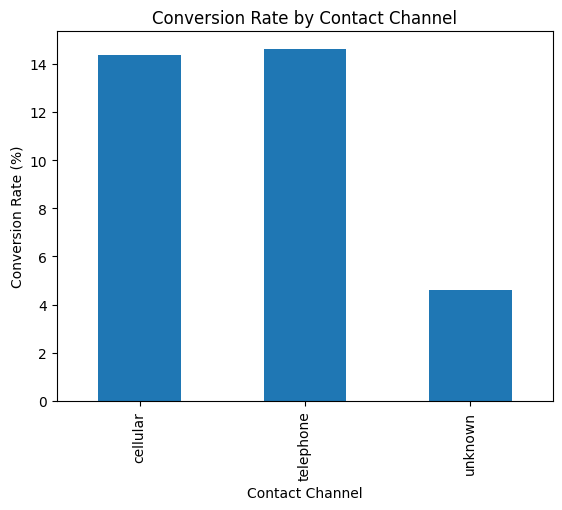

In [13]:
import matplotlib.pyplot as plt

channel_analysis['conversion_rate'].plot(kind='bar')

plt.title("Conversion Rate by Contact Channel")

plt.ylabel("Conversion Rate (%)")

plt.xlabel("Contact Channel")

plt.show()

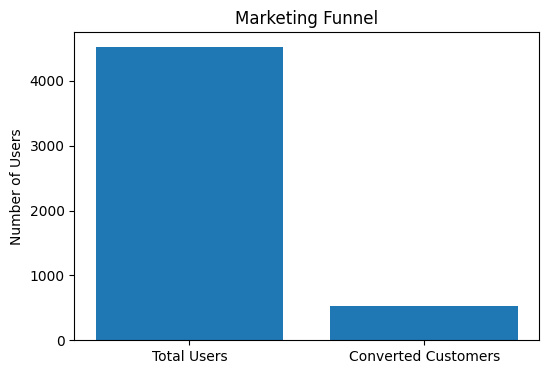

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(funnel['Stage'], funnel['Count'])

plt.title("Marketing Funnel")

plt.ylabel("Number of Users")

plt.show()

In [16]:
funnel.to_csv("../dashboard/funnel_data.csv", index=False)

channel_analysis.to_csv("../dashboard/channel_analysis.csv")

campaign_analysis.to_csv("../dashboard/campaign_analysis.csv")

print("Files exported successfully!")

Files exported successfully!


In [17]:
funnel.to_csv("../dashboard/funnel_data.csv", index=False)

channel_analysis.to_csv("../dashboard/channel_analysis.csv")

campaign_analysis.to_csv("../dashboard/campaign_analysis.csv")

print("Files exported successfully!")

Files exported successfully!


# Key Insights & Recommendations

## Insights
- Overall conversion rate is low, showing major drop-off in the funnel.
- Certain contact channels perform better than others.
- Repeated campaign contacts may reduce conversion effectiveness.

## Recommendations
1. Focus marketing budget on high-converting channels.
2. Reduce excessive customer contact attempts.
3. Improve customer targeting strategies.
4. Optimize follow-up communication.
5. Monitor conversion KPIs regularly.